<a href="https://colab.research.google.com/github/Dervain-Valbrune/app_idea/blob/main/test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

from sklearn.linear_model import LinearRegression

from sklearn.metrics import mean_absolute_error, r2_score

from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt

In [ ]:
donnees = pd.DataFrame({
    'Surface': [60, 80, 45, 100, 70, 90, 55, 120, 65, 85, 50, 110, 75, 95, 40],
    'Chambres': [2, 3, 1, 4, 2, 3, 2, 4, 2, 3, 1, 4, 3, 3, 1],
    'Distance': [5, 3, 8, 2, 6, 1, 7, 4, 3, 5, 9, 2, 4, 3, 10],
    'Prix': [280000, 350000, 200000, 450000, 300000, 420000, 240000, 500000,
             310000, 370000, 210000, 480000, 330000, 400000, 180000]
})


In [ ]:
donnees.describe()

# donnees.isnull().sum()

,Surface,Chambres,Distance,Prix
count,15.000000,15.000000,15.000000,15.000000
mean,76.000000,2.533333,4.800000,334666.666667
std,24.068355,1.060099,2.704494,102180.978567
min,40.000000,1.000000,1.000000,180000.000000
25%,57.500000,2.000000,3.000000,260000.000000
50%,75.000000,3.000000,4.000000,330000.000000
75%,92.500000,3.000000,6.500000,410000.000000
max,120.000000,4.000000,10.000000,500000.000000


In [ ]:
X = donnees[['Surface']]
Y = donnees['Prix']

print('Entree X - 5 premieres lignes')
print(X.head())

print()
print('Sortie Y - 5 premieres lignes')
print(Y.head())


Entree X - 5 premieres lignes
   Surface
0       60
1       80
2       45
3      100
4       70

Sortie Y - 5 premieres lignes
0    280000
1    350000
2    200000
3    450000
4    300000
Name: Prix, dtype: int64


In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y,
        test_size = 0.2, # 20% pour le test
        random_state = 42  # fixe le hasard pour avoir toujours les memes resultats
           )

print("Taille jeu d'entrainement: ", len(X_train), "exemples")
print('Taille jeu de test: ', len(X_test), 'exemples')

Taille jeu d'entrainement:  12 exemples
Taille jeu de test:  3 exemples


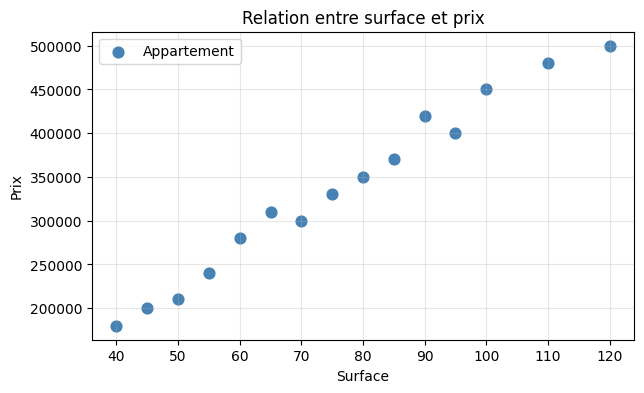

In [ ]:
plt.figure(figsize=(7, 4))

plt.scatter(donnees['Surface'], donnees['Prix'], color='steelblue',
            s=60, label='Appartement')
plt.xlabel('Surface')
plt.ylabel('Prix')
plt.title("Relation entre surface et prix")
plt.legend()
plt.grid(True, alpha = 0.3)
plt.show()

In [ ]:
modele = LinearRegression()
modele.fit(X_train, Y_train)

LinearRegression()

In [ ]:
a = modele.coef_[0]
b = modele.intercept_

print('Droite de regression trouvee:')
print(f"Prix = {a: .2f} x Surface + {b: .2f}")
print()

print(f"augmente le prix de {a: .2f} points en moyenne")

Droite de regression trouvee:
Prix =  4226.88 x Surface +  12434.06

augmente le prix de  4226.88 points en moyenne


In [ ]:
Y_pred = modele.predict(X_test)

resultats = pd.DataFrame({
    'Surface': X_test['Surface'].values,
    'Notes reelles': Y_test.values,
    'Notes predites': Y_pred.round(1)
})

print(resultats.to_string(index=False))

 Surface  Notes reelles  Notes predites
      85         370000        371719.1
     110         480000        477391.2
      60         280000        266047.0


In [ ]:
# Calcul MAE et R2

mae = mean_absolute_error(Y_test, Y_pred)

r2 = r2_score(Y_test, Y_pred)

print(f"MAE(erreur moyenne) {mae: .2f} points")
print(f"R2(qualite modele) {r2: .2f}")

print()
print(f"Le modele se trompe de {mae: .2f} points")
print(f"Il explique {r2*100: .1f}% des variations de prix")

MAE(erreur moyenne)  6093.63 points
R2(qualite modele)  0.99

Le modele se trompe de  6093.63 points
Il explique  99.0% des variations de prix


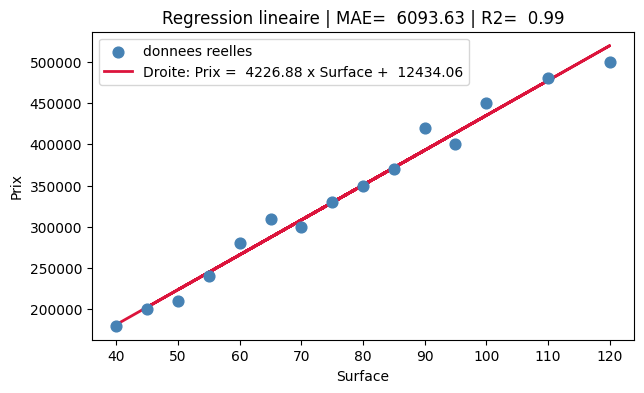

In [ ]:
Y_droite = modele.predict(X)

plt.figure(figsize=(7,4))
plt.scatter(donnees['Surface'], donnees['Prix'], color='steelblue', s=60,
            label='donnees reelles', zorder=3)

# droite de regression
plt.plot(donnees['Surface'], Y_droite, color='crimson', linewidth=2,
         label = f"Droite: Prix = {a: .2f} x Surface + {b: .2f}")
plt.xlabel('Surface')
plt.ylabel('Prix')
plt.title(f"Regression lineaire | MAE= {mae: .2f} | R2= {r2: .2f}")
plt.legend()
plt.show()

In [ ]:
X_multi = donnees[['Surface', 'Chambres', 'Distance']]
Y_multi = donnees['Prix']

X_train2, X_test2, Y_train2, Y_test2 = train_test_split(
    X_multi, Y_multi, test_size=0.2, random_state=42
)

modele2 = LinearRegression()
modele2.fit(X_train2, Y_train2)

a1 = modele2.coef_[0]
a2 = modele2.coef_[1]
a3 = modele2.coef_[2]
b1 = modele2.intercept_

print('Droite de regression trouvee: ')
print(f"Prix= {a1: .2f} x Surface + {a2: .2f} x Chambres + {a3: .2f} x Distance + {b1: .2f}")
print()

print(f"- Chaque surface ajoute de {a1: .2f} points et chaque chambre ajoute de {a2: .2f} points")
print(f"- Chaque distance retire de {a3: .2f} points")

Droite de regression trouvee: 
Prix=  3519.97 x Surface +  1945.19 x Chambres + -6608.58 x Distance +  92910.64

- Chaque surface ajoute de  3519.97 points et chaque chambre ajoute de  1945.19 points
- Chaque distance retire de -6608.58 points


In [ ]:
Y_pred2 = modele2.predict(X_test2)

mae2 = mean_absolute_error(Y_test2, Y_pred2)
r2_2 = r2_score(Y_test2, Y_pred2)

print("=== Comparaison de deux modeles ===")
print(f"Modele simple: -> MAE = {mae: .2f} | R2 = {r2: .2f}")

print(f"Modele complexe(3 variables): -> MAE = {mae2: .2f} | R2 = {r2_2: .2f}")
print()
if r2_2 > r2:
  print("Oui! Le R2 avec 3 variables est plus eleve")
else:
  print("Pas vraiment sur ce petit jeu de donnees")

=== Comparaison de deux modeles ===
Modele simple: -> MAE =  6093.63 | R2 =  0.99
Modele complexe(3 variables): -> MAE =  5157.03 | R2 =  1.00

Oui! Le R2 avec 3 variables est plus eleve


In [ ]:
donnees2 = pd.DataFrame({
    'Surface' : [88],
    'Chambres' : [3],n
    'Distance' : [4]
})
donnees2

,Surface,Chambres,Distance
0,88,3,4


In [ ]:
prediction = modele2.predict(donnees2)
print(f"Prix prédit : {prediction[0]:.2f}")

Prix prédit : 382069.55
